# Setup

In [1]:
import scvi
import scrnatools as rna
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import celltypist
import os
import shutil
import anndata as ad
import scanpy as sc

In [2]:
# Setup seeds
scvi.settings.seed = 0

Seed set to 0


In [3]:
# Setup figure params
plt.rcParams["pdf.use14corefonts"] = True
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = "Arial"
sc.set_figure_params(dpi=80, dpi_save=300, facecolor="white", frameon=False)
sns.set_context("paper")
plt.rcParams["axes.grid"] = False
cmap = sns.color_palette("colorblind")
# Get the tab20 colormap
tab20_cmap = plt.get_cmap('tab20')

# Create a new colormap without the 7th and 8th colors
colors_to_exclude = [6, 7]  # 0-based index, so 6 and 7 represent the 7th and 8th colors
new_tab20 = [tab20_cmap(i) for i in range(tab20_cmap.N) if i not in colors_to_exclude]

## Set data paths

### demeter

In [7]:
rawDataPath = "/mnt/iacchus/joe/raw_data/"
processedDataPath = "/mnt/iacchus/joe/processed_data/"

# Import raw data

## Aire KO/WT

### Sample 1

#### WT

In [8]:
Aire_WT_1 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Yi/kallisto/Aire_WT-1/counts_unfiltered/adata.h5ad",
)

#### Aire KO

In [9]:
Aire_KO_1 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Yi/kallisto/Aire_KO-1/counts_unfiltered/adata.h5ad",
)

### Sample 2

#### WT

In [10]:
Aire_WT_2 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Aire_KO/kallisto/Aire_WT-2/counts_unfiltered/adata.h5ad",
)


#### Aire KO

In [11]:
Aire_KO_2 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Aire_KO/kallisto/Aire_KO-2/counts_unfiltered/adata.h5ad",
)

## Fezf2 KO/WT

### Sample 1

#### WT

In [12]:
Fezf2_WT_1 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Fezf2_KO/kallisto/Fezf2_WT-1/counts_unfiltered/adata.h5ad",
)

#### Fezf2 KO

In [13]:
Fezf2_KO_1 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Fezf2_KO/kallisto/Fezf2_KO-1/counts_unfiltered/adata.h5ad",
)

### Sample 2

#### WT

In [14]:
Fezf2_WT_2 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Fezf2_KO/kallisto/Fezf2_WT-2/counts_unfiltered/adata.h5ad",
)

#### Fezf2 KO

In [15]:
Fezf2_KO_2 = sc.read_h5ad(
    f"{rawDataPath}/Thymus/Fezf2_KO/kallisto/Fezf2_KO-2/counts_unfiltered/adata.h5ad",
)

# Merge data

In [16]:
adata = ad.concat(
    [Aire_WT_1, Aire_WT_2, Fezf2_WT_1, Fezf2_WT_2, Aire_KO_1, Aire_KO_2, Fezf2_KO_1, Fezf2_KO_2],
    label="batch",
    index_unique="-",
    keys=["Aire_WT-1", "Aire_WT-2", "Fezf2_WT-1", "Fezf2_WT-2", "Aire_KO-1", "Aire_KO-2", "Fezf2_KO-1", "Fezf2_KO-2"],   
)
adata.layers["raw_counts"] = adata.X.copy()
adata.obs["genotype"] = [i.split("-")[0] for i in adata.obs.batch]
adata.obs["genotype"] = [i.split("_")[1] if "WT" in i else i for i in adata.obs.genotype]
adata.obs["sample"] = [i.split("-")[1] for i in adata.obs.batch]

# Preprocessing

In [17]:
# Get biomart gene annotations
adata.var["ensembl_gene"] = [i.split(".")[0] for i in adata.var_names]
gene_info = sc.queries.biomart_annotations("mmusculus", ["ensembl_gene_id", "external_gene_name", "gene_biotype"])
gene_info.index = gene_info.ensembl_gene_id
gene_info = gene_info[gene_info.index.isin(adata.var.ensembl_gene)]
gene_info = gene_info.drop_duplicates(subset="external_gene_name")
adata = adata[:, adata.var.ensembl_gene.isin(gene_info.index)].copy()
adata.var = adata.var.join(gene_info, on="ensembl_gene")
# Drop transcripts with no gene name
adata = adata[:, ~adata.var.external_gene_name.isna()].copy()
# Annotate mito genes
adata.var["mt"] = adata.var.external_gene_name.str.startswith("mt-")
# Get qc metrics for each cell, gene
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False,)
# Subset on protein coding genes
adata = adata[:, adata.var.gene_biotype.isin(["protein_coding"])].copy()
# Basic prefiltering of lowly detected genes/empty droplets
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.filter_cells(adata, min_genes=100)
adata.var.index = adata.var.external_gene_name

In [18]:
adata

AnnData object with n_obs × n_vars = 297704 × 19869
    obs: 'batch', 'genotype', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'ensembl_gene', 'ensembl_gene_id', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

# Scrublet doublet removal

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.15
Detected doublet rate = 12.1%
Estimated detectable doublet fraction = 38.0%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 31.9%
Elapsed time: 198.8 seconds
Detected doublet rate = 3.2%
Estimated detectable doublet fraction = 14.9%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 21.4%
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.30
Detected doublet rate = 0.0%
Estimated detectable doublet fraction = 0.0%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 100.0%
Elapsed time: 61.8 seconds
Detected doublet rate = 0.4%
Estimated detectable doublet fraction = 1.5%
Overall doublet rate:
	Expected   = 6.0%
	Estimated  = 28.7%
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Cal

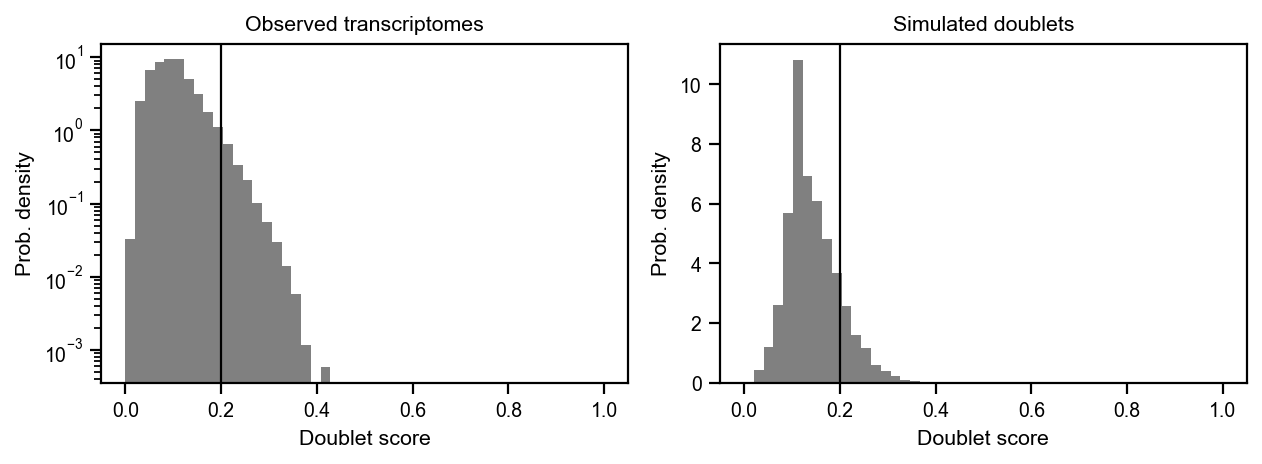

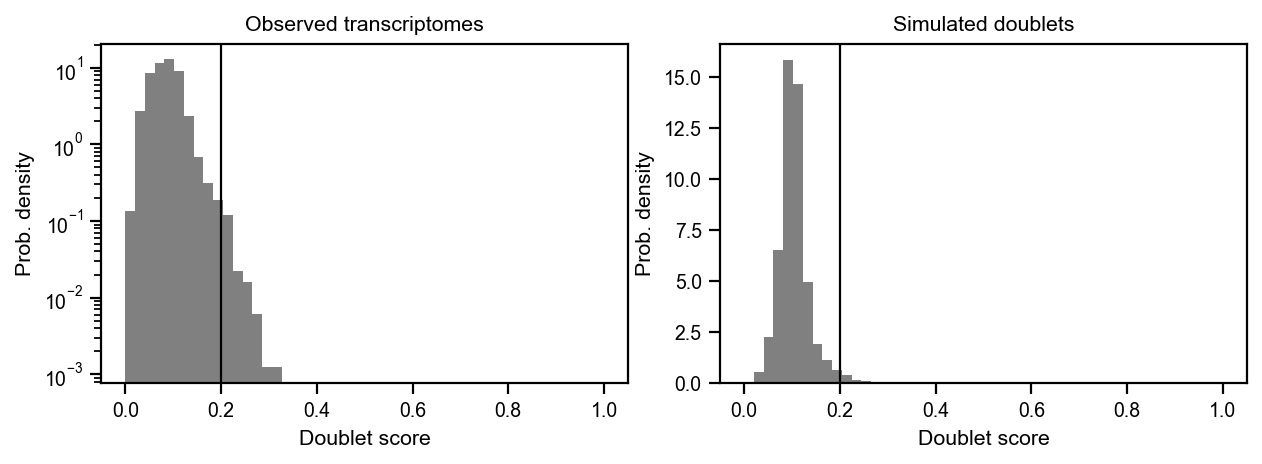

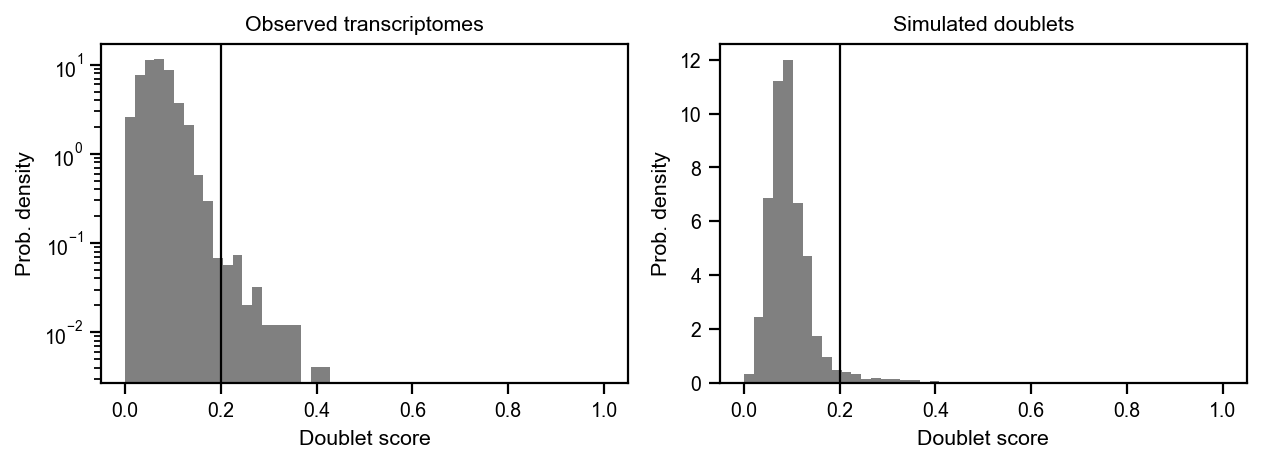

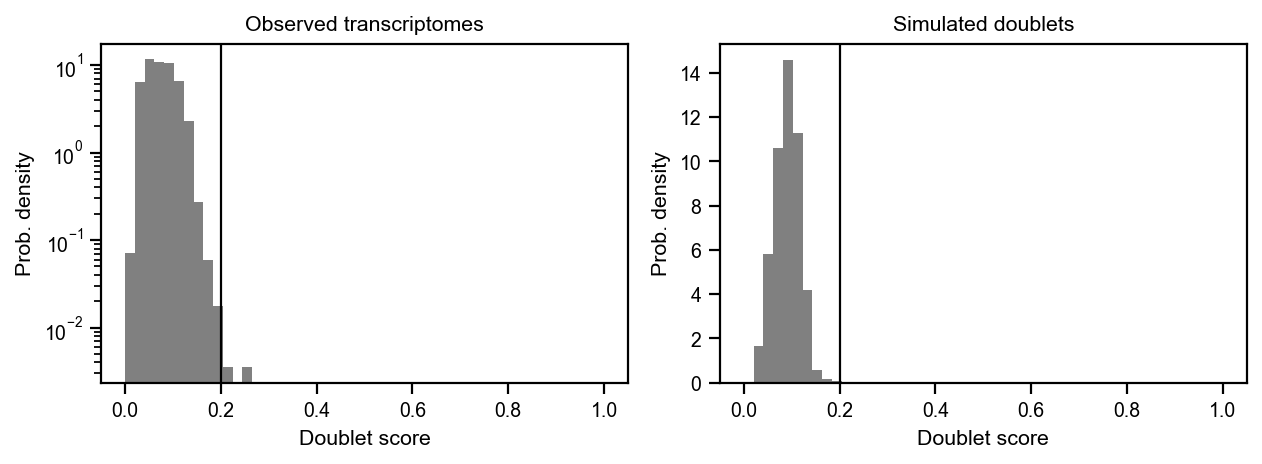

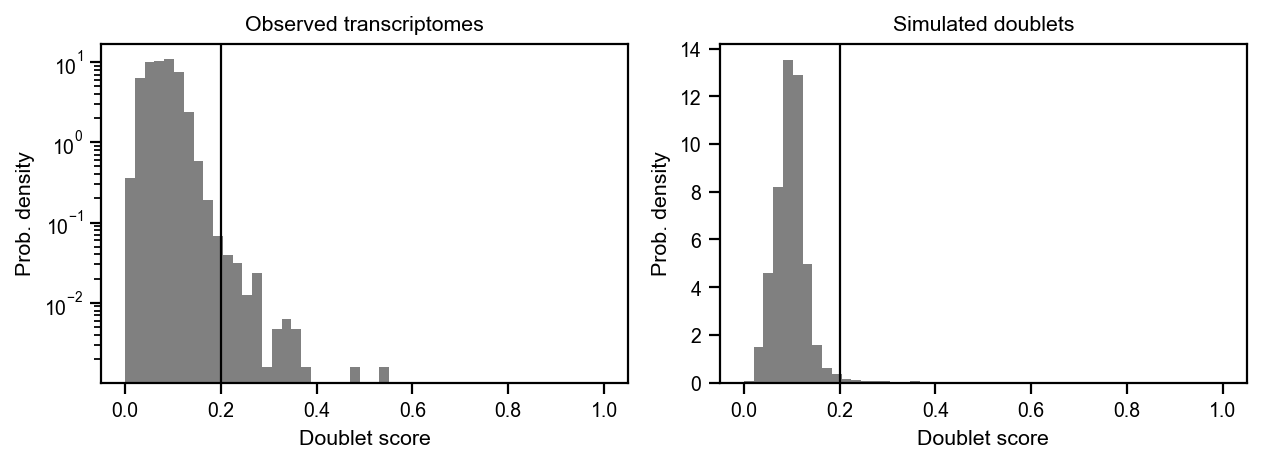

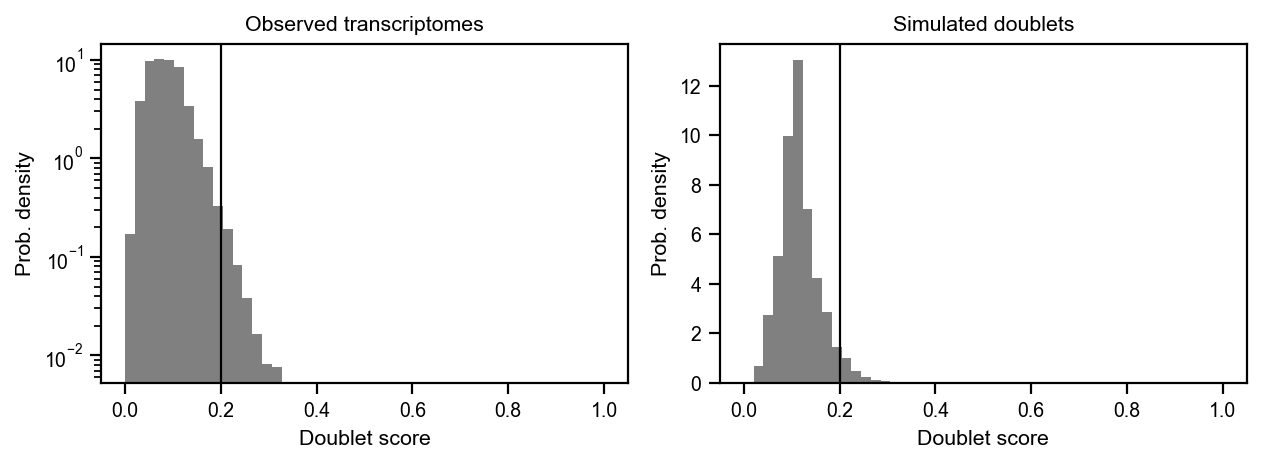

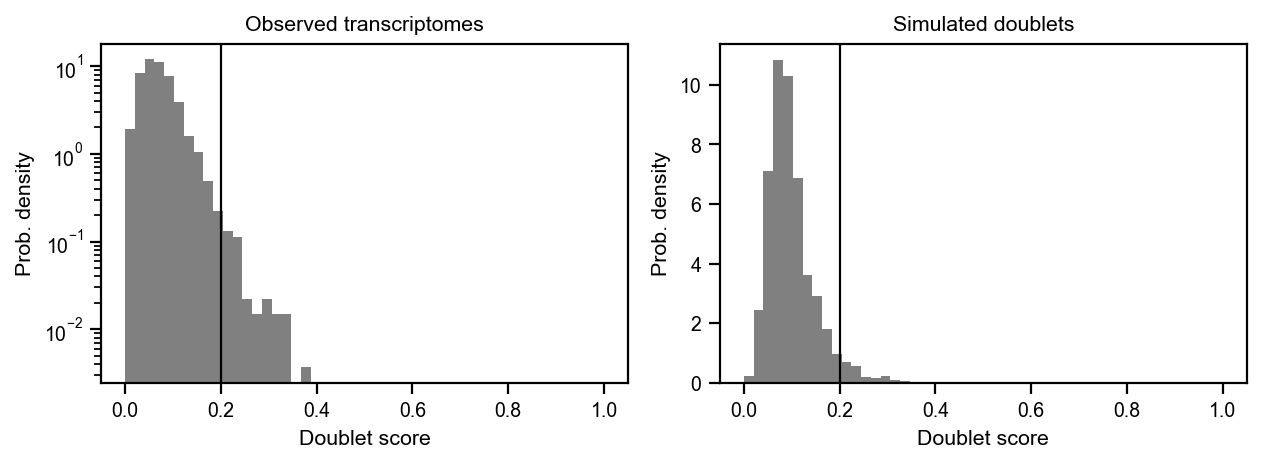

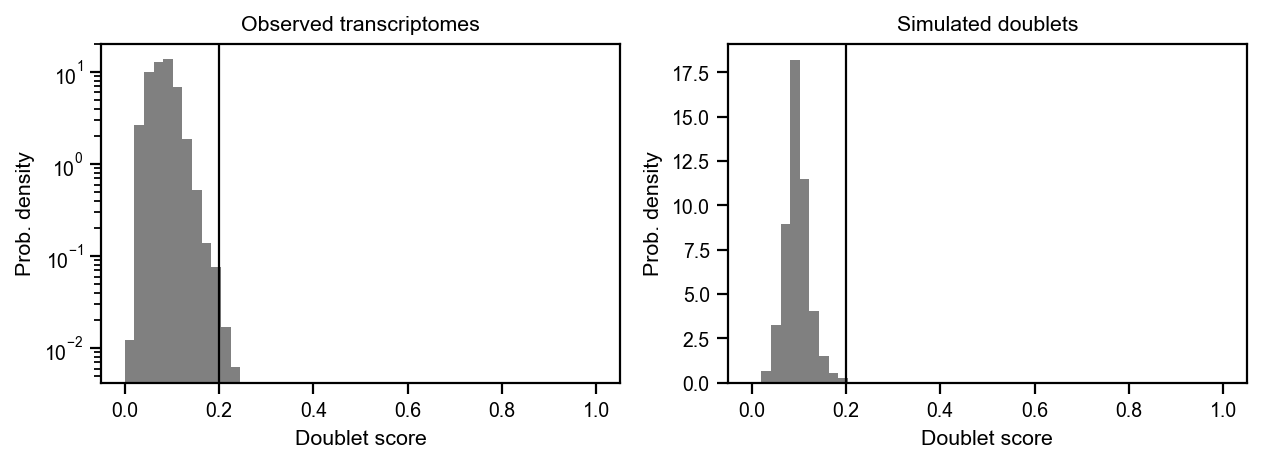

In [19]:
adata = rna.qc.scrublet(
    adata,
    doublet_threshold = 0.2,
    batch_key = "batch",
    raw_counts_layer = "raw_counts",
    subset=False,
)

In [20]:
adata = adata[~adata.obs.scrublet_called_doublet].copy()

In [21]:
adata.obs.genotype.value_counts()

WT          147418
Aire_KO     101748
Fezf2_KO     44840
Name: genotype, dtype: int64

## QC filter

In [22]:
adata

AnnData object with n_obs × n_vars = 294006 × 19869
    obs: 'batch', 'genotype', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_score', 'scrublet_called_doublet'
    var: 'ensembl_gene', 'ensembl_gene_id', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

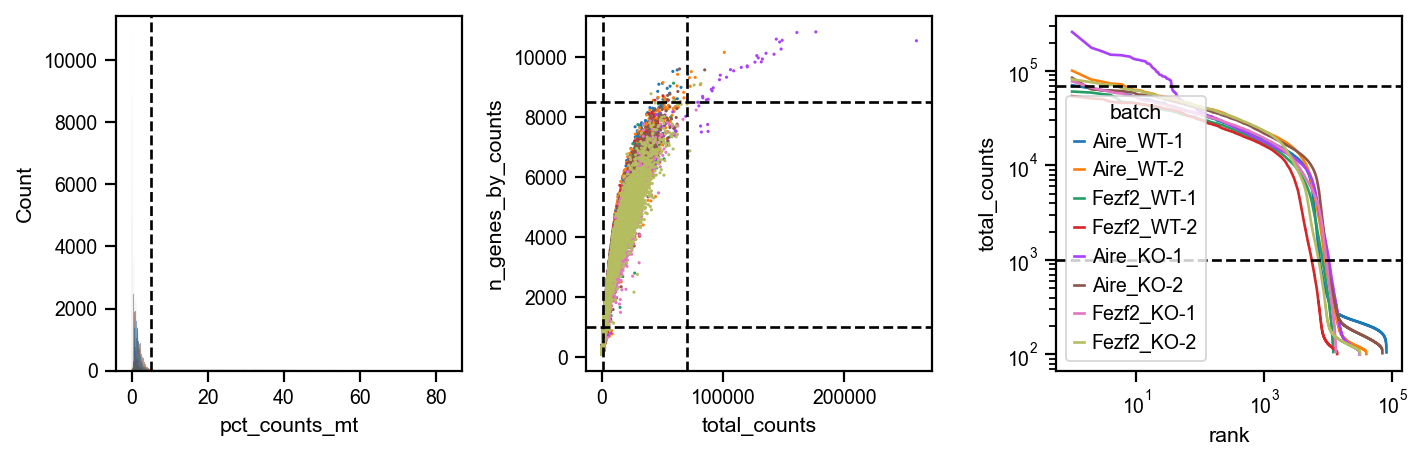

In [23]:
# Set thresholds
countsThreshold = [1000, 70000]
genesThreshold = [1000, 8500]
mtThreshold = 5
# Check QC thresholds before filtering
rna.pl.qc_plotting(
    adata,
    batch_key="batch",
    counts_thresholds=countsThreshold,
    genes_thresholds=genesThreshold,
    mt_threshold=mtThreshold,
)

In [ ]:
filteredAdata = rna.qc.filter_cells(
    adata,
    counts_thresholds=countsThreshold, 
    genes_thresholds=genesThreshold, 
    mt_threshold=mtThreshold,
)

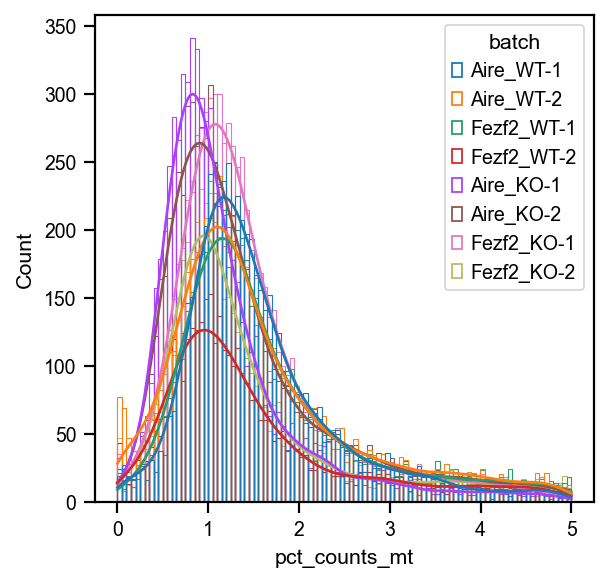

In [21]:
sns.histplot(
    adata.obs,
    x="pct_counts_mt",
    hue="batch",
    kde=True,
    fill=False
)
plt.savefig("../../analysis/preprocessing/pct_mt.pdf")
plt.show()

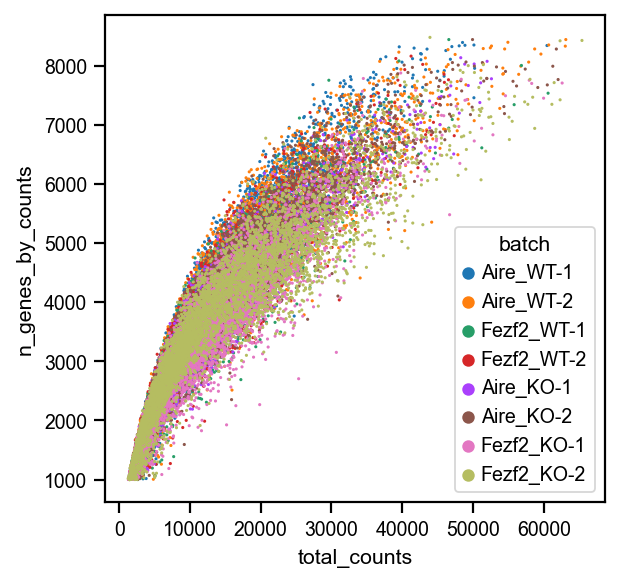

In [22]:
sns.scatterplot(
    adata.obs,
    x="total_counts",
    y="n_genes_by_counts",
    hue="batch",
    s=2,
    linewidth=0
)
plt.savefig("../../analysis/preprocessing/qc_vars.pdf")
plt.show()

In [25]:
# overwrite original adata variable with the filtered data
adata = filteredAdata.copy()
del filteredAdata

In [26]:
adata

AnnData object with n_obs × n_vars = 53533 × 19869
    obs: 'batch', 'genotype', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'scrublet_score', 'scrublet_called_doublet'
    var: 'ensembl_gene', 'ensembl_gene_id', 'external_gene_name', 'gene_biotype', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'raw_counts'

In [27]:
adata.obs.genotype.value_counts()

WT          23724
Aire_KO     16395
Fezf2_KO    13414
Name: genotype, dtype: int64

## Normalize data (scanpy)

In [28]:
# Scanpy preprocessing pipeline
adata.raw = adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["log1p"] = adata.X.copy()

# scVI training

In [29]:
# Save pre-integration data
adata_unintegrated = adata.copy()
adata_unintegrated.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_no_integration.h5ad")

... storing 'genotype' as categorical
... storing 'sample' as categorical
... storing 'gene_biotype' as categorical
... storing 'gene_biotype' as categorical


In [30]:
# Setup scVI model using raw counts and batch info
scvi.model.SCVI.setup_anndata(
    adata,
    layer="raw_counts",
    batch_key="batch",
)
model = scvi.model.SCVI(adata)

Unable to initialize backend 'cuda': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [31]:
# Train scVI model
model.train(
    early_stopping=True,
    max_epochs=1000,
    accelerator="gpu",
    devices="auto" 
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 3090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 294/1000:  29%|██▉       | 294/1000 [17:14<41:23,  3.52s/it, v_num=1, train_loss_step=8.72e+3, train_loss_epoch=9.91e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 9999.614. Signaling Trainer to stop.


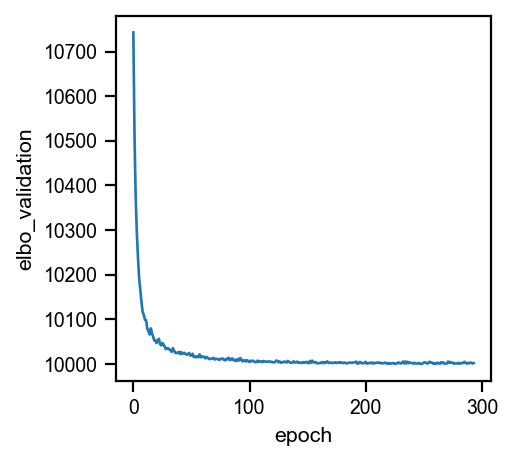

In [32]:
# Plot model ELBO
plt.figure(figsize=(3,3))
ax = sns.lineplot(model.history['elbo_validation'])
plt.ylabel("elbo_validation")
ax.get_legend().remove()
plt.show()

In [33]:
# get scVI latent space and normalized expression
adata.obsm["X_scVI"] = model.get_latent_representation()
adata.layers["scVI_normalized"] = model.get_normalized_expression(library_size=1e4)

In [34]:
# Dimensionality reduction
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)

... storing 'genotype' as categorical
... storing 'sample' as categorical
... storing 'gene_biotype' as categorical


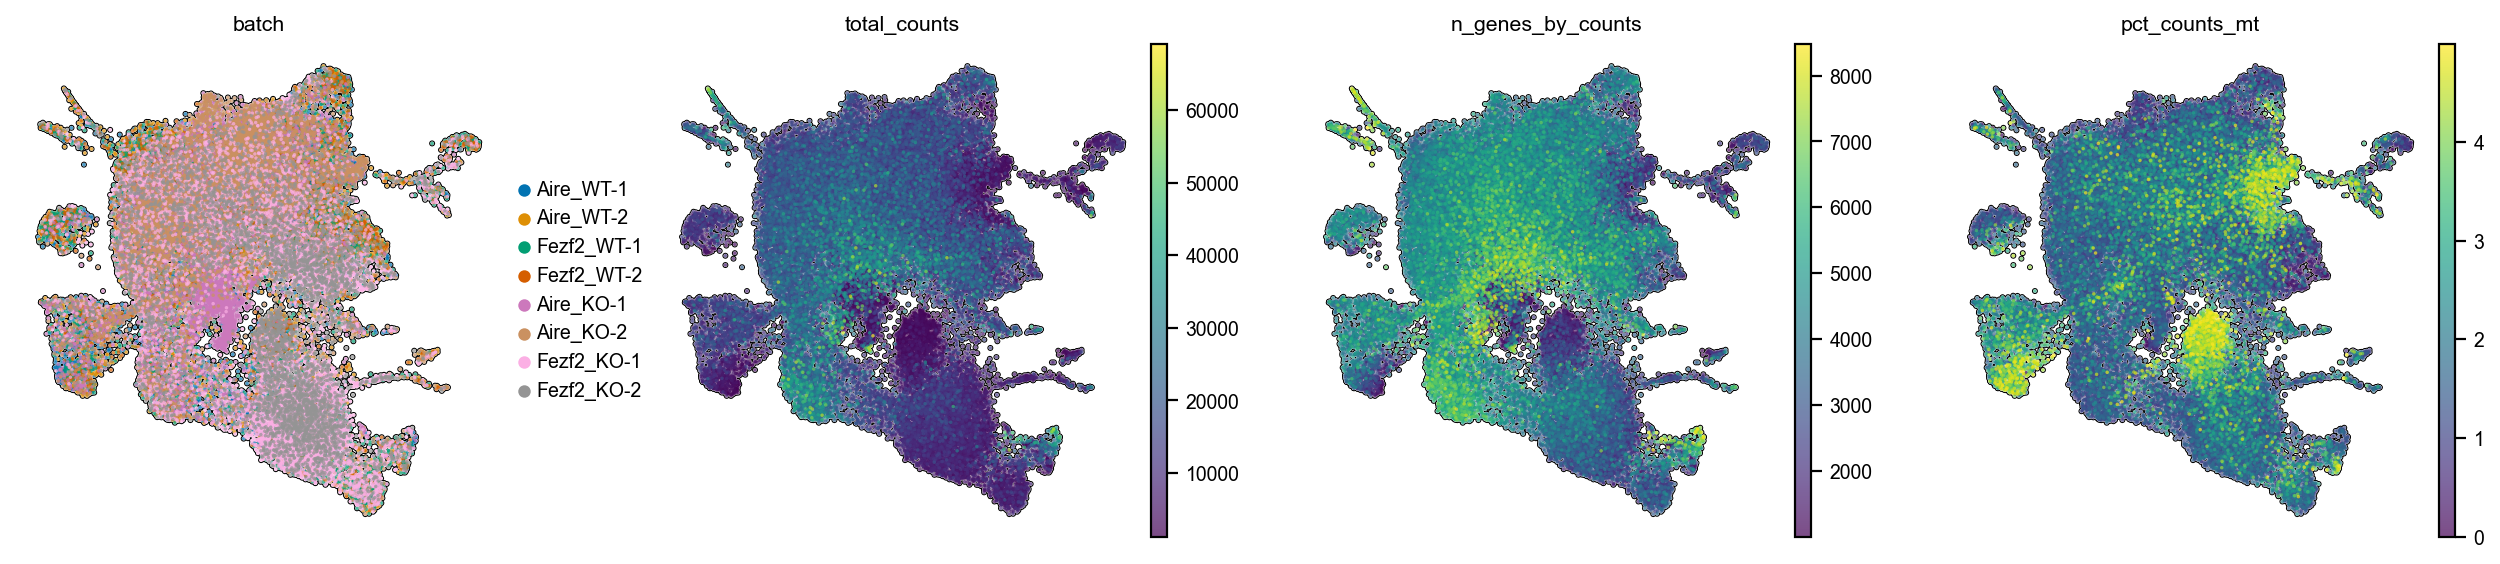

In [35]:
sc.settings.figdir = "../../analysis/preprocessing/"
sc.pl.umap(
    adata,
    color=["batch", "total_counts", "n_genes_by_counts", "pct_counts_mt"],
    s=10,
    add_outline=True,
    save="_qc_vars.pdf",
    palette=cmap,
)

# Clustering

In [36]:
sc.tl.leiden(adata, key_added="leiden_scVI", resolution=0.4)

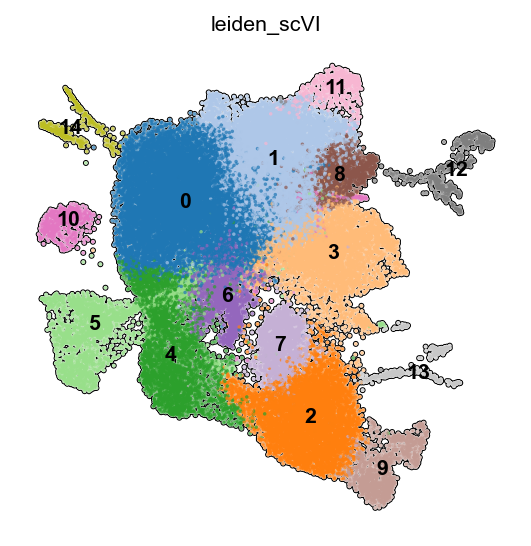

In [37]:
sc.settings.figdir = "../../analysis/preprocessing/"
sc.pl.umap(
    adata,
    color=["leiden_scVI"],
    legend_loc="on data",
    palette=new_tab20,
    s=10,
    add_outline=True,
    save="_initial_clustering.pdf"
)

# Identify contaminates

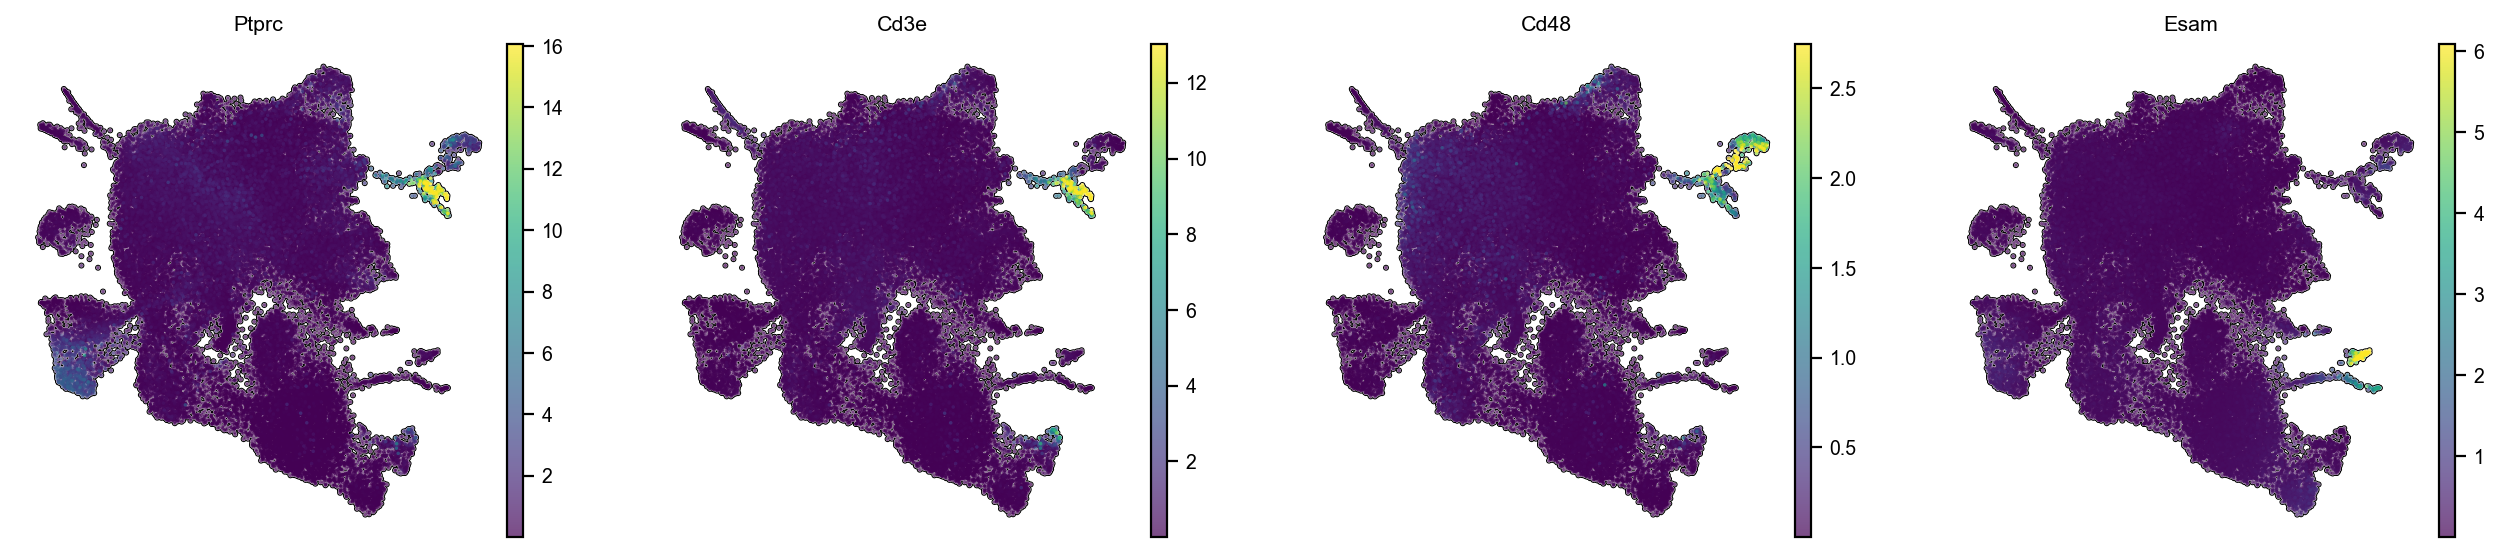

In [38]:
sc.settings.figdir = "../../analysis/preprocessing/"
geneList = ["Ptprc", "Cd3e", "Cd48", "Esam"]
rna.pl.gene_embedding(  
    adata,
    gene_list=geneList,
    layer="scVI_normalized",
    cmap="viridis",
    s=10,
    min_quantile=0.001,
    max_quantile=0.999,
    add_outline=True,
    save="_qc_expression.pdf"
)

# Remove contaminating clusters

In [39]:
filteredAdata = adata[~adata.obs.leiden_scVI.isin(["6", "12", "13"])].copy()

In [40]:
filteredAdata.obs.genotype.value_counts()

WT          22993
Aire_KO     14448
Fezf2_KO    12951
Name: genotype, dtype: int64

# Recompute UMAP

In [41]:
# Dimensionality reduction
sc.pp.neighbors(filteredAdata, use_rep="X_scVI")
sc.tl.umap(filteredAdata)

In [42]:
filteredAdata.obs.genotype = filteredAdata.obs.genotype.cat.reorder_categories(["WT", "Aire_KO", "Fezf2_KO"])

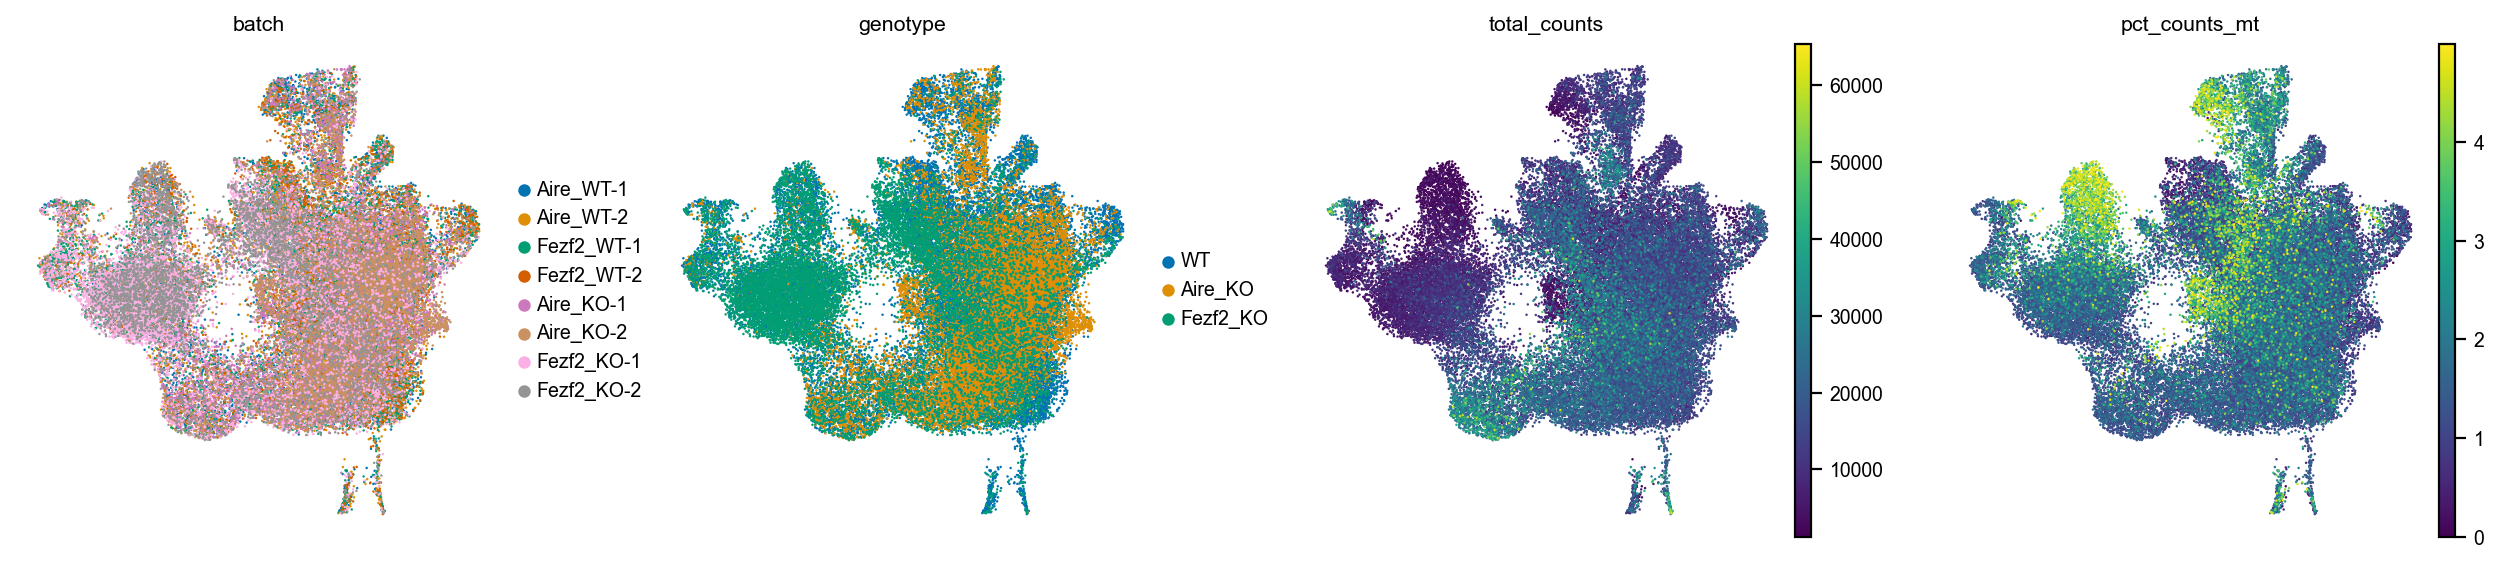

In [43]:
sc.pl.umap(
    filteredAdata,
    color=["batch", "genotype", "total_counts", "pct_counts_mt"],
    s=5,
    palette=cmap
)

# Celltypist label transfer

In [44]:
# Import reference data
michelson = sc.read_10x_mtx(
    f"{rawDataPath}/Thymus/Michelson_2022/scRNAseq/adult_perinate_gex",
    prefix="GSM5831744_adult_perinate_gex_",
    cache=True,
)
metadata = pd.read_csv(
    f"{rawDataPath}/Thymus/Michelson_2022/scRNAseq/GSM5831744_adult_perinate_metadata.txt",
    index_col=0,
    sep=" "
)
annotations = pd.read_csv(
    f"{rawDataPath}/Thymus/Michelson_2022/scRNAseq/20230707_mtec_scrnaseq_metadata.txt",
    index_col=0,
    sep="\t"
)

# Subset on annotated cells
michelson = michelson[michelson.obs_names.isin(metadata.index)]
michelson.obs = michelson.obs.join(metadata)
michelson.obs = michelson.obs.join(annotations)

# Basic preprocessing
michelson.layers["raw_counts"] = michelson.X.copy()
sc.pp.filter_genes(michelson, min_cells=20)
gene_info = sc.queries.biomart_annotations("mmusculus", ["ensembl_gene_id", "external_gene_name", "gene_biotype"])
gene_info = gene_info.drop_duplicates(subset="external_gene_name")
gene_info.index = gene_info.external_gene_name
del gene_info["external_gene_name"]
gene_info = gene_info[gene_info.index.isin(michelson.var_names)]
michelson = michelson[:, michelson.var_names.isin(gene_info.index)]
michelson.var = michelson.var.join(gene_info)
michelson = michelson[:, michelson.var.gene_biotype.isin(["protein_coding"])].copy()

# log transform
sc.pp.normalize_total(michelson, target_sum = 1e4)
sc.pp.log1p(michelson)

In [45]:
# Feature selection
model_fs = celltypist.train(
    michelson,
    'cluster',
    n_jobs = 10,
    max_iter = 5,
    use_SGD = True
)
gene_index = np.argpartition(np.abs(model_fs.classifier.coef_), -300, axis = 1)[:, -300:]
gene_index = np.unique(gene_index)
print(f"Number of genes selected: {len(gene_index)}")

🍳 Preparing data before training
🔬 Input data has 8236 cells and 15155 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/sklearn/linear_model/_stochastic_gradient.py:744: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
✅ Model training done!


Number of genes selected: 4491


In [46]:
# Train celltypist model
celltypist_model = celltypist.train(
    michelson[:, gene_index],
    'cluster',
    n_jobs = 10,
    max_iter = 1000,
    check_expression = False,
)

🍳 Preparing data before training
🔬 Input data has 8236 cells and 4491 genes
⚖️ Scaling input data
🏋️ Training data using logistic regression
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
✅ Model training done!


In [47]:
# Ensure X contains log1p data
filteredAdata.X = filteredAdata.layers["log1p"].copy()
# Get celltypist predictions
predictions = celltypist.annotate(
    filteredAdata,
    model=celltypist_model,
    majority_voting=True
)

🔬 Input data has 50392 cells and 19869 genes
🔗 Matching reference genes in the model
🧬 4478 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


In [48]:
filteredAdata = predictions.to_adata()

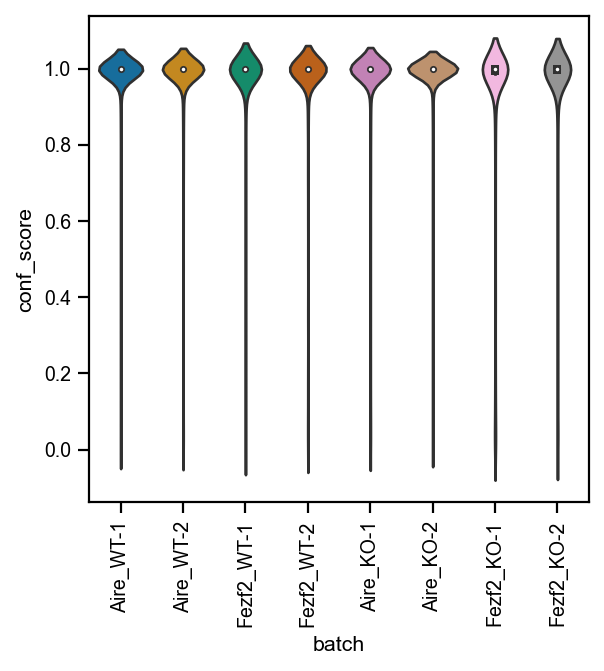

In [49]:
ax = sns.violinplot(
    filteredAdata.obs,
    x="batch",
    y="conf_score",
    palette=cmap
)
ax.grid(False)
plt.xticks(rotation=90)
plt.show()

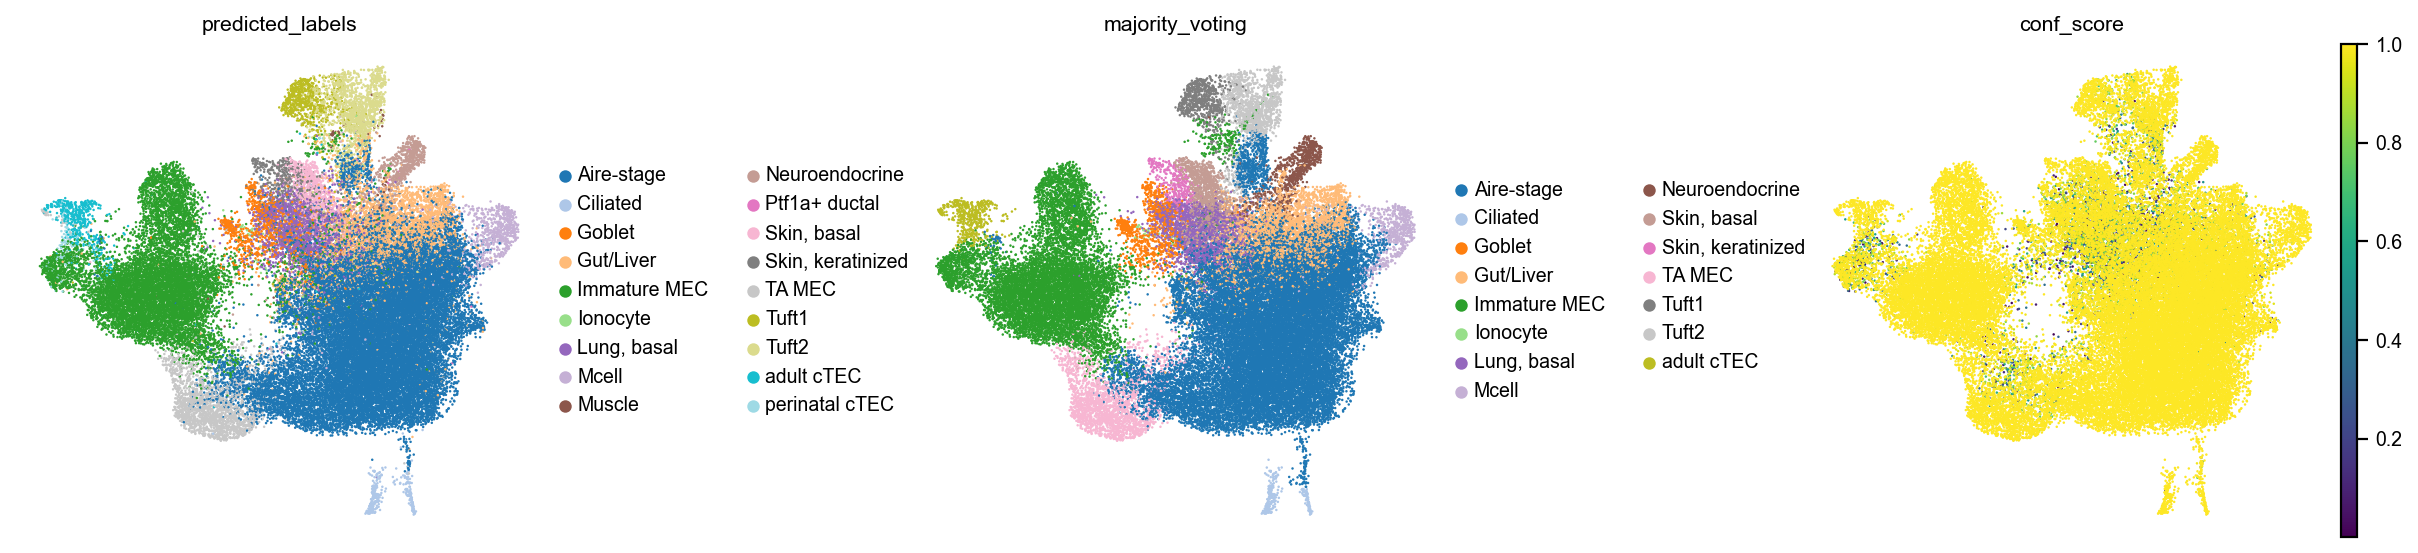

In [50]:
sc.settings.figdir = "../../analysis/preprocessing/"
sc.pl.umap(
    filteredAdata,
    color=["predicted_labels", "majority_voting", "conf_score"],
    s=5,
    wspace=0.55,
    save="_cell_type_qc.pdf",
    palette=new_tab20
)

# Save data

In [51]:
# Check save paths
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models")
    
if not os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files"):
    os.makedirs(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files")
    
if os.path.isdir(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/combined_all_genes"):
    shutil.rmtree(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/combined_all_genes")
    
model.save(f"{processedDataPath}/Fezf2_thymus_paper/scVI_models/combined_all_genes")
celltypist_model.write(f"{processedDataPath}/Fezf2_thymus_paper/michelson_thymus_celltypist_model.pkl")
adata.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes.h5ad")
filteredAdata.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_TECs.h5ad")
michelson.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/michelson_reference.h5ad")

... storing 'gene_biotype' as categorical
... storing 'gene_biotype' as categorical
... storing 'hash_ident' as categorical
... storing 'cluster' as categorical
... storing 'feature_types' as categorical
... storing 'gene_biotype' as categorical


In [7]:
filteredAdata = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_TECs.h5ad")

In [8]:
adata = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes.h5ad")

# Integration analysis

In [52]:
# Subset on same cells
adata_unintegrated = adata_unintegrated[adata_unintegrated.obs_names.isin(filteredAdata.obs_names)].copy()
adata_unintegrated.obs["majority_voting"] = filteredAdata.obs.majority_voting
# Compute PCA/neighbors/UMAP for unintegrated data
sc.tl.pca(adata_unintegrated)
sc.pp.neighbors(adata_unintegrated)
sc.tl.umap(adata_unintegrated)
# Copy embedding to be used for integration scoring
adata_unintegrated.obsm["X_emb"] = adata_unintegrated.obsm["X_pca"].copy()
# Update saved unintegrated data
adata_unintegrated.write(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_no_integration.h5ad")

In [53]:
adata_unintegrated = sc.read(f"{processedDataPath}/Fezf2_thymus_paper/h5ad_files/combined_all_genes_no_integration.h5ad")

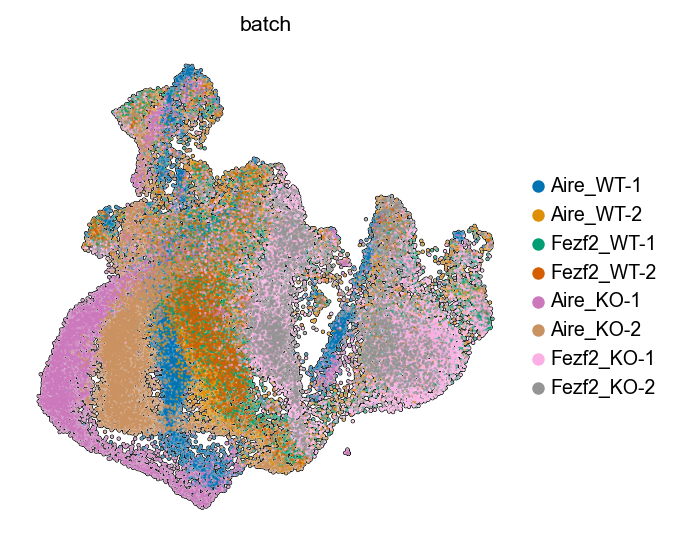

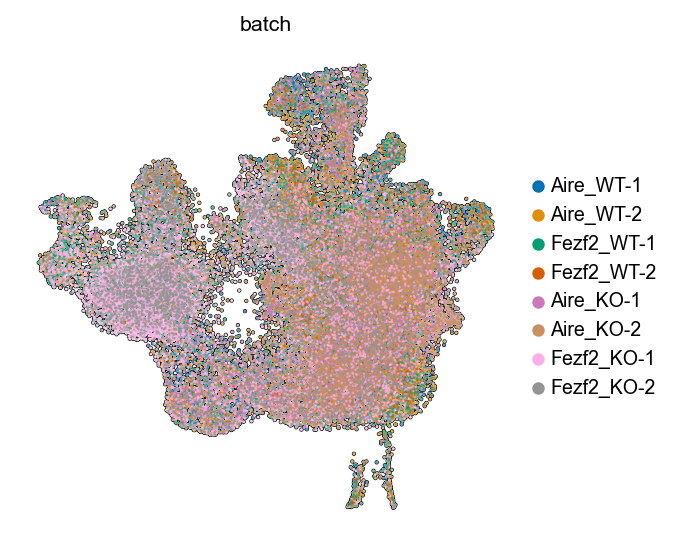

In [54]:
sc.settings.figdir = "../../analysis/preprocessing/"
sc.pl.umap(
    adata_unintegrated,
    color="batch",
    save="_before_integration.pdf",
    palette=cmap,
    add_outline=True,
    s=5
)
sc.pl.umap(
    filteredAdata,
    color="batch",
    save="_after_integration.pdf",
    palette=cmap,
    add_outline=True,
    s=5
)

In [55]:
# Copy embedding to be used for integration scoring
filteredAdata.obsm["X_emb"] = filteredAdata.obsm["X_scVI"].copy()

In [56]:
WT_data_unintegrated = adata_unintegrated[adata_unintegrated.obs.genotype == "WT"].copy()
WT_data = filteredAdata[filteredAdata.obs.genotype == "WT"].copy()

In [57]:
Aire_data_unintegrated = adata_unintegrated[adata_unintegrated.obs.genotype == "Aire_KO"].copy()
Aire_data = filteredAdata[filteredAdata.obs.genotype == "Aire_KO"].copy()

In [58]:
Fezf2_data_unintegrated = adata_unintegrated[adata_unintegrated.obs.genotype == "Fezf2_KO"].copy()
Fezf2_data = filteredAdata[filteredAdata.obs.genotype == "Fezf2_KO"].copy()

## WT

In [59]:
import scib

In [61]:
wt_metrics = scib.metrics.metrics(
    WT_data_unintegrated,
    WT_data,
    batch_key="batch",
    label_key="majority_voting",
    embed="X_emb",
    type_="embed",
    n_cores=12,
    graph_conn_=True,
    ilisi_=True,
    kBET_=True,
    pcr_=True,
    silhouette_=True
)
wt_metrics.columns = ["WT"]

Silhouette score...
PC regression...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


Graph connectivity...
kBET...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


iLISI score...


## Aire_KO

In [62]:
aire_metrics = scib.metrics.metrics(
    Aire_data_unintegrated,
    Aire_data,
    batch_key="batch",
    label_key="majority_voting",
    embed="X_emb",
    type_="embed",
    n_cores=12,
    graph_conn_=True,
    ilisi_=True,
    kBET_=True,
    pcr_=True,
    silhouette_=True
)
aire_metrics.columns = ["Aire_KO"]

Silhouette score...
PC regression...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


Graph connectivity...
kBET...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and wi

Ciliated consists of a single batch or is too small. Skip.
Ionocyte consists of a single batch or is too small. Skip.
iLISI score...


## Fezf2_KO

In [63]:
fezf2_metrics = scib.metrics.metrics(
    Fezf2_data_unintegrated,
    Fezf2_data,
    batch_key="batch",
    label_key="majority_voting",
    embed="X_emb",
    type_="embed",
    n_cores=12,
    graph_conn_=True,
    ilisi_=True,
    kBET_=True,
    pcr_=True,
    silhouette_=True
)
fezf2_metrics.columns = ["Fezf2_KO"]

Silhouette score...
PC regression...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(
/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/anndata/_core/anndata.py:453: PendingDeprecationWarning: The dtype argument will be deprecated in anndata 0.10.0
  warnings.warn(


Graph connectivity...
kBET...


/home/joe/anaconda3/envs/fezf2-thymus-env/lib/python3.9/site-packages/scib/metrics/kbet.py:229: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


Adding diffusion to step 4
iLISI score...


In [64]:
pd.concat([wt_metrics, aire_metrics, fezf2_metrics], axis=1)

,WT,Aire_KO,Fezf2_KO
NMI_cluster/label,NaN,NaN,NaN
ARI_cluster/label,NaN,NaN,NaN
ASW_label,0.562360,0.562599,0.591955
ASW_label/batch,0.933150,0.933097,0.947115
PCR_batch,0.893936,0.896527,0.733240
cell_cycle_conservation,NaN,NaN,NaN
isolated_label_F1,NaN,NaN,NaN
isolated_label_silhouette,NaN,NaN,NaN
graph_conn,0.986042,0.813534,0.735513
kBET,0.767913,0.849761,0.899045
